# Обучение классификатора отзывов

## Подготовка датасета

Ссылка на исходный датасет - https://www.kaggle.com/datasets/kyakovlev/yandex-geo-reviews-dataset-2023

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("geo-reviews-dataset-2023.csv")
df

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...
...,...,...,...,...,...
499995,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ..."
499996,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,По сравнению со многими современными платформа...
499997,"Новосибирск, Коммунистическая улица, 48А",NaN,5.0,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная..."
499998,"Астраханская область, Харабалинский район",Сарай-Бату,5.0,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...


In [2]:
df.rating.value_counts()

rating
5.0    390515
4.0     41160
1.0     34351
3.0     21686
2.0     12088
0.0       200
Name: count, dtype: int64

#### Стратегия подготовки данных для бинарной классификации отзывов:

Для решения задачи автоматического обнаружения критических отзывов мы применяем следующую логику трансформации исходных данных:


Мы преобразуем числовые рейтинги в бинарные метки согласно бизнес-целям:

| Класс | Значение `label` | Критерий рейтинга | Бизнес-смысл |
| :--- | :---: | :--- | :--- |
| **Негативный** | **1** | Рейтинг ≤ 2 | Критические отзывы, требующие **немедленной реакции** поддержки или менеджмента. Модель обучается приоритетно искать именно этот класс. |
| **Позитивный** | **0** | Рейтинг ≥ 4 | Успешный опыт клиента. Эти отзывы не требуют срочного вмешательства и служат фоновым классом («нормой») для обучения. |

Отзывы с рейтингом **3** полностью удаляются из датасета перед обучением.\
**Обоснование:** Нейтральные оценки часто неоднозначны по тональности. Их наличие может «размыть» границу принятия решений моделью, снизив её способность четко различать полярные случаи (явно плохо vs явно хорошо).


In [3]:
df_prepared = df[(df['rating'] <= 2) | (df['rating'] >= 4)].copy()

# Дедупликация по тексту отзыва
df_prepared = df_prepared.drop_duplicates(subset=['text'], keep='first').copy()

# Создание целевой переменной (label)
# 1 — негативный отзыв (рейтинг <= 2)
# 0 — позитивный отзыв (рейтинг >= 4)
df_prepared['label'] = (df_prepared['rating'] <= 2).astype(int)

# Сброс индекса
df_prepared = df_prepared.reset_index(drop=True)

In [4]:
df_prepared

,address,name_ru,rating,rubrics,text,label
0,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ...",0
1,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я...",1
2,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...,0
3,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...,0
4,"Иркутская область, Черемхово, Первомайская ули...",Tele2,5.0,Оператор сотовой связи;Интернет-провайдер,"Приятное общение, все доступно объяснили, мне ...",0
...,...,...,...,...,...,...
478194,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ...",0
478195,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,По сравнению со многими современными платформа...,0
478196,"Новосибирск, Коммунистическая улица, 48А",NaN,5.0,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная...",0
478197,"Астраханская область, Харабалинский район",Сарай-Бату,5.0,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...,0


In [5]:
df_prepared.label.value_counts()

label
0    431560
1     46639
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

# ==========================================================================================================
# Разделение на train / validation / test с сохранением пропорций классов 70% трейн 10% валидация и 20% тест
# ==========================================================================================================

# Шаг 1: Отделяем тестовую выборку (20% от всего датасета)
# stratify по label сохраняет пропорцию классов (0 и 1)
df_train_val, df_test = train_test_split(
    df_prepared,
    test_size=0.2,           # 20% на тест
    random_state=42,         # фиксируем случайность для воспроизводимости
    stratify=df_prepared['label'],  # сохраняем пропорцию классов
)

# Шаг 2: Разделяем оставшиеся 80% на train (70%) и validation (10%)
# 10% / 80% = 0.125 (12.5% от оставшихся данных пойдут на валидацию)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.125,         # 12.5% от 80% = 10% от общего датасета
    random_state=42,
    stratify=df_train_val['label'],  # сохраняем пропорцию классов
)

# Сбрасываем индексы для удобства
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [7]:
print(f"\nОбщий размер: {len(df_prepared)} отзывов")
print(f"\nРазмеры выборок:")
print(f"  Train:      {len(df_train)} ({len(df_train)/len(df_prepared)*100:.1f}%)")
print(f"  Validation: {len(df_val)}   ({len(df_val)/len(df_prepared)*100:.1f}%)")
print(f"  Test:       {len(df_test)}  ({len(df_test)/len(df_prepared)*100:.1f}%)")

print(f"\nРаспределение классов на train:")
print(df_train['label'].value_counts(normalize=True).sort_index())


Общий размер: 478199 отзывов

Размеры выборок:
  Train:      334739 (70.0%)
  Validation: 47820   (10.0%)
  Test:       95640  (20.0%)

Распределение классов на train:
label
0    0.90247
1    0.09753
Name: proportion, dtype: float64


## Приступаем к обучению моделей

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
from tqdm.auto import tqdm
import os
import random
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

### Основные параметры модели:

Модель что будем использовать для тюнинга - https://huggingface.co/intfloat/multilingual-e5-small

In [9]:
# Задаем параметры
MODEL_NAME = 'intfloat/multilingual-e5-small'
BATCH_SIZE = 256
MAX_LENGTH = 64
NUM_EPOCHS = 10
RANDOM_SEED = 42

In [10]:
def seed_all(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(RANDOM_SEED)

Рассмотрим работу токенизатора

In [11]:
# Инициализируем токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [12]:
text = "Всем привет я Дмитрий! Добро пожаловать на лекцию по NLP"
encoding = tokenizer(
    text,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
    return_tensors='pt'
)
print(encoding)

{'input_ids': tensor([[     0,   7762,    130, 146038,    784, 154888,     38,  71133, 149558,
          27224,     29,  30031,  22959,    129,    541,  37352,      2,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}


In [13]:
from termcolor import colored

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
attention_mask = encoding['attention_mask'][0]
input_ids = encoding['input_ids'][0].tolist()

# Собираем только полезные токены (без PAD)
real_tokens = [t for t, m in zip(tokens, attention_mask) if m == 1]
real_ids = [id_ for id_, m in zip(input_ids, attention_mask) if m == 1]

# Цвета для чередования
colors = ['red', 'green', 'yellow', 'blue', 'magenta', 'cyan', 'white']

# Заголовок с номерами токенов
print("\n№ токена:  ", end='')
for i in range(len(real_tokens)):
    print(colored(f'{i:^7}', 'white'), end='')
print()

# Разделитель
print("           " + "─"*7 * len(real_tokens))

# Строка с токенами
print("Токены:    ", end='')
for i, token in enumerate(real_tokens):
    color = colors[i % len(colors)]
    display = token.replace('▁', '_')
    print(colored(f'{display:^7}', color), end='')
print()

# Строка с ID токенов
print("ID:        ", end='')
for i, token_id in enumerate(real_ids):
    color = colors[i % len(colors)]
    print(colored(f'{token_id:^7}', color), end='')
print()



№ токена:     0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16   
           ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Токены:      <s>   _Все     м   _привет  _я   _Дмитрий   !   _Добро _пожал  овать   _на   _лек    цию    _по    _N     LP    </s>  
ID:           0    7762    130  146038   784  154888   38    71133 149558  27224   29    30031  22959   129    541   37352    2   


Создаем класс датасета который представит данные уже в токенизированной форме - https://huggingface.co/blog/tokenizers 

In [14]:
# Создаем датасет
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.texts = df.text.tolist()
        self.labels = df.label.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.float)
        }

In [15]:
# Создаем датасеты и даталоадеры
train_dataset = TextDataset(
    df_train,
    tokenizer
)

val_dataset = TextDataset(
    df_val,
    tokenizer
)

test_dataset = TextDataset(
    df_test,
    tokenizer
)

In [16]:
train_dataset[200]

{'input_ids': tensor([     0,   3858,    546,  47981,    183,  19108,      5,   1087,  76291,
          27752,    244,   1009, 100414,    559,      5, 153191,   6103,     29,
            190,   1328,   1203,  24405,   5509,     35,  73013,  25172,   5509,
              5,   1087,  72794,  55057,     35, 150314,      9,   3549, 124107,
             49,     61,  41341,     59,  29015, 224193,  10130,     15,   2180,
            130,  13636,  34358,      4, 110378,  16051,      4,   1045,   1707,
              4,  43526,    415,    194, 153191,   6103,    255,    744,  66813,
              2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'label': tensor(0.)}

In [17]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
batch = next(iter(train_loader))
batch

{'input_ids': tensor([[     0,   1721,  26958,  ...,  36562, 146038,      2],
         [     0, 212309,   2192,  ...,  41661,   9977,      2],
         [     0,   7762, 213683,  ...,      1,      1,      1],
         ...,
         [     0,   5188, 121760,  ...,      1,      1,      1],
         [     0,   3858,    546,  ...,      1,      1,      1],
         [     0,  61421,     89,  ...,      1,      1,      1]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'label': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
    

In [19]:
batch["input_ids"].shape

torch.Size([256, 64])

In [20]:
batch["attention_mask"].shape

torch.Size([256, 64])

In [21]:
batch["label"].shape

torch.Size([256])

Число спусков на 1 эпоху

In [22]:
len(train_loader)

1308

### Выбираем модель для fine tuning

In [23]:
# Модель для классификации
class E5Classifier(nn.Module):
    def __init__(self, model_name='intfloat/multilingual-e5-small', num_labels=1):
        super(E5Classifier, self).__init__()
        self.e5 = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.e5.config.hidden_size, num_labels)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.e5(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # Берем embedding первого токена [CLS - <s>]
        logits = self.classifier(pooled_output)
        return logits.squeeze(-1)


In [24]:
# Инициализируем модель
model = E5Classifier(model_name=MODEL_NAME, num_labels=1)

In [25]:
model

E5Classifier(
  (e5): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250037, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_a

In [26]:
# Функция для вычисления числа параметров
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

count_parameters(model)

(117654145, 117654145)

In [27]:
# Функция для вычисления метрик
def compute_metrics(predictions, labels, threshold=0.5):
    predictions_binary = (predictions > threshold).astype(int)
    accuracy = accuracy_score(labels, predictions_binary)
    f1 = f1_score(labels, predictions_binary)
    precision = precision_score(labels, predictions_binary)
    recall = recall_score(labels, predictions_binary)
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [28]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = "mean"):
        """
        Focal Loss для бинарной классификации.
        
        Parameters
        ----------
        alpha : torch.Tensor
            Веса классов размером [2] для [класс_0, класс_1].
            Пример: torch.tensor([0.75, 0.25])
        gamma : float
            Параметр фокусировки. По умолчанию 2.0.
        reduction : str
            'mean', 'sum' или 'none'.
        """
        super().__init__()
        # Гарантируем, что alpha — это тензор с плавающей точкой
        self.alpha = alpha.float()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        inputs : torch.Tensor
            Логиты модели (без сигмоиды), форма [Batch, ...]
        targets : torch.Tensor
            Метки классов (0 или 1), форма [Batch, ...]
        """
        assert inputs.shape == targets.shape, f"Shape mismatch: {inputs.shape} vs {targets.shape}"
        
        # Приводим targets к long для gather и float для BCE
        targets_long = targets.long()
        targets_float = targets.float()

        # 1. Бинарная кросс-энтропия без редукции
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets_float, reduction="none"
        )

        # 2. Вероятность правильного класса (p_t)
        p_t = torch.exp(-bce_loss)

        # 3. Выбор веса alpha для каждого пикселя/элемента
        # Перемещаем alpha на то же устройство, что и данные
        alpha = self.alpha.to(inputs.device)
        
        # gather выбирает вес: если target=0 -> alpha[0], если target=1 -> alpha[1]
        alpha_t = alpha.gather(0, targets_long.view(-1)).view_as(targets)

        # 4. Фокусирующий коэффициент (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma

        # 5. Итоговый лосс
        loss = alpha_t * focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

In [29]:
def train_model(model, train_loader, val_loader, test_loader, device, num_epochs=5):
    model.to(device)
    
    # Инициализация оптимизатора, функции потерь и планировщика
    # Расчет параметров
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(0.05 * total_steps)  # 5% warmup

    loss_func = FocalLoss(
        alpha=torch.tensor([0.5, 1.0]), 
        gamma=2.5
    )

    optimizer = AdamW(
        model.parameters(), 
        lr=3e-5, 
        weight_decay=0.01
    )

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps, 
        num_training_steps=total_steps
    )
    
    # Списки для сохранения истории лоссов (для построения графиков)
    train_losses = []
    val_losses = []
    
    best_val_f1 = 0
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        
        # --- TRAIN ---
        model.train()
        total_train_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Training', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = loss_func(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
        
        train_losses.append(total_train_loss / len(train_loader))
        
        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        val_predictions = []
        val_labels = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Validation', leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                
                outputs = model(input_ids, attention_mask)
                
                # Считаем лосс валидации для графика
                loss = loss_func(outputs, labels)
                total_val_loss += loss.item()
                
                # Предсказания нужны только для расчета F1 (отбор лучшей модели)
                predictions = torch.sigmoid(outputs).cpu().numpy()
                val_predictions.extend(predictions)
                val_labels.extend(labels.cpu().numpy())
        
        val_losses.append(total_val_loss / len(val_loader))
        
        # Расчет метрик только для условия сохранения
        val_metrics = compute_metrics(np.array(val_predictions), np.array(val_labels))
        current_f1 = val_metrics['f1']
        val_acc = val_metrics['accuracy']
        
        print(f'Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val accuracy: {val_acc:.3f} | Val F1: {current_f1:.3f}')
        
        if current_f1 > best_val_f1:
            best_val_f1 = current_f1
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model weights updated due to improved validation F1 score")
    
    print(f'\nTraining Complete. Best validation F1: {best_val_f1:.4f}')
    
    # Возвращаем модель и историю лоссов
    return model, train_losses, val_losses

In [31]:
# Запуск обучения 
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

final_model, train_l, val_l = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Epoch 1/10


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0178 | Val Loss: 0.0116 | Val accuracy: 0.969 | Val F1: 0.848
Model weights updated due to improved validation F1 score

Epoch 2/10


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0034 | Val Loss: 0.0197 | Val accuracy: 0.973 | Val F1: 0.860

Epoch 10/10


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0031 | Val Loss: 0.0210 | Val accuracy: 0.972 | Val F1: 0.858

Training Complete. Best validation F1: 0.8623


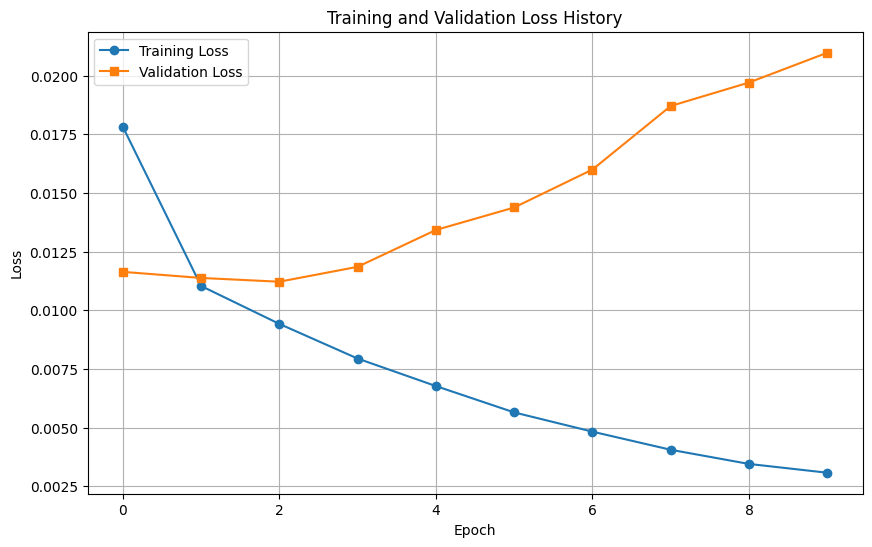

In [49]:
# Построение графика лосса от эпох
plt.figure(figsize=(10, 6))
plt.plot(train_l, label='Training Loss', marker='o')
plt.plot(val_l, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss History')
plt.legend()
plt.grid(True)
plt.show()

### Оценим качество на тесте

In [50]:
# Загружаем лучшую модель для финального тестирования
model.load_state_dict(torch.load('best_model.pth'))
model.to(device).eval()

final_predictions = []
final_labels = []

# Сбор предсказаний на тестовом наборе
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids, attention_mask)
        predictions = torch.sigmoid(outputs).cpu().numpy()
        
        final_predictions.extend(predictions)
        final_labels.extend(labels.cpu().numpy())

# Конвертация в массивы
final_predictions = np.array(final_predictions).ravel()  # Важно: flatten для бинарной задачи
final_labels = np.array(final_labels).ravel()

  0%|          | 0/374 [00:00<?, ?it/s]

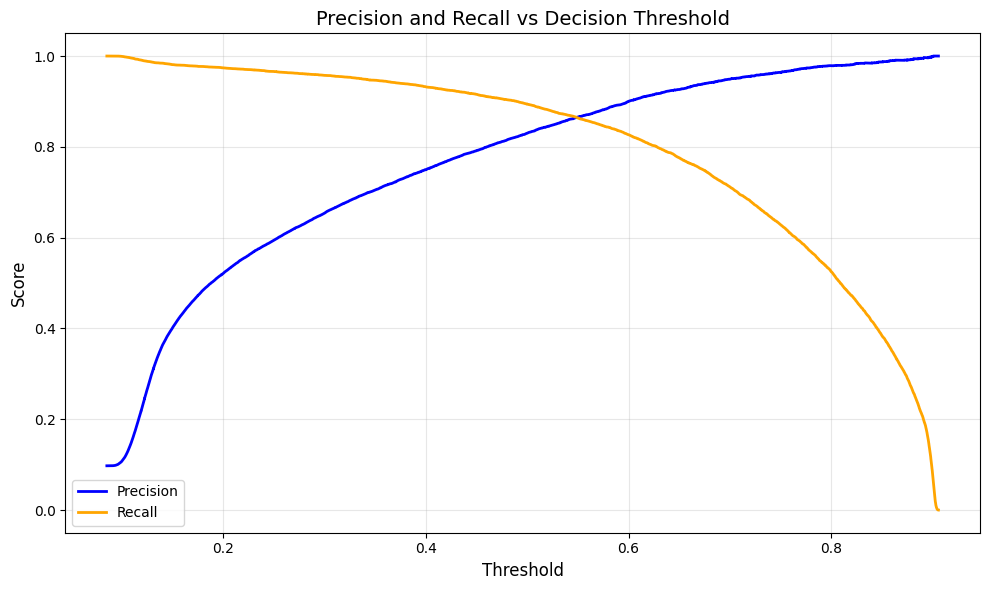

In [52]:
# --- Precision-Recall vs Threshold ---
# Расчет метрик для разных порогов
precisions, recalls, thresholds = precision_recall_curve(final_labels, final_predictions)

# Построение графика зависимости от порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2, color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2, color='orange')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs Decision Threshold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT (threshold=0.5)
              precision    recall  f1-score   support

         0.0     0.9885    0.9802    0.9843     86312
         1.0     0.8301    0.8941    0.8609      9328

    accuracy                         0.9718     95640
   macro avg     0.9093    0.9372    0.9226     95640
weighted avg     0.9730    0.9718    0.9723     95640


CONFUSION MATRIX (threshold=0.5)


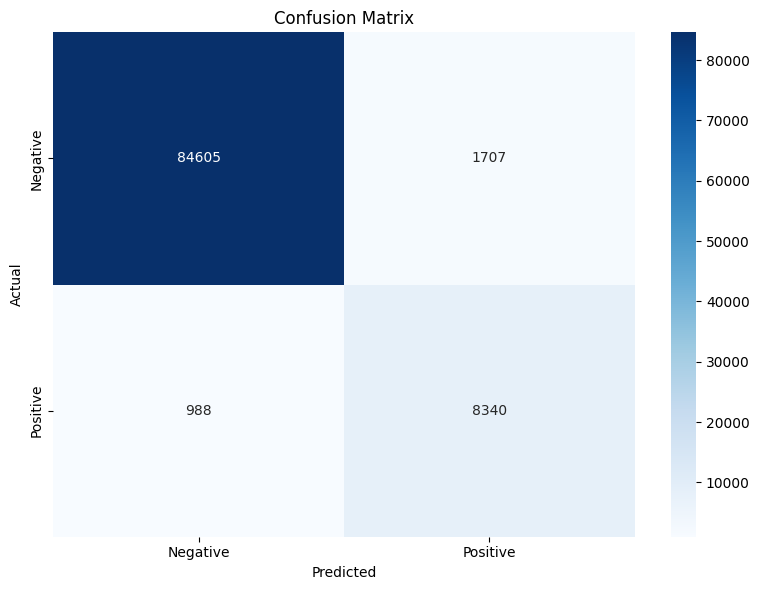

In [53]:
# Бинаризация предсказаний для основных метрик
threshold = 0.5
final_predictions_binary = (final_predictions > threshold).astype(int)

# --- Classification Report ---
print('\n' + '='*50)
print(f'CLASSIFICATION REPORT (threshold={threshold})')
print('='*50)
print(classification_report(final_labels, final_predictions_binary, digits=4))

# --- Confusion Matrix ---
print('\n' + '='*50)
print(f'CONFUSION MATRIX (threshold={threshold})')
print('='*50)
cm = confusion_matrix(final_labels, final_predictions_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Отсмотрим ошибки FP FN

In [54]:
# Добавляем столбцы в датафрейм
df_test['model_score'] = final_predictions
df_test['predicted_label'] = (final_predictions > 0.5).astype(int)

# Выводим примеры FP (ложные срабатывания)
fp_df = df_test[(df_test['predicted_label'] == 1) & (df_test['label'] == 0)]
print(f"\nFalse Positives (FP): {len(fp_df)}")
print("="*80)
for idx, row in fp_df.sample(min(5, len(fp_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Positives (FP): 1707
СКОР от модели: 0.7231
Rating на сайте: 5.0000
ТЕКСТ: Занятие на фитболе хорошее.Записалась вечером на тренировку и запллатила 750р,но утром из за ребенка не смогла пойти.Позвонила за 20минут до тренировкн,ни кто не ответил.Так как работают с 10,а тренир...
--------------------------------------------------------------------------------
СКОР от модели: 0.5843
Rating на сайте: 5.0000
ТЕКСТ: Срочно нужна была мойка.... А по пути всё они были на другой стороне.... Вообщем нашёл её случайно! \nМашину помыл за 150 руб.... Сам не верю.... \nМного таксистов... Но я проскочил.... \nРекомендую.....
--------------------------------------------------------------------------------
СКОР от модели: 0.8512
Rating на сайте: 4.0000
ТЕКСТ: Странное место. По меню абсолютный не ресторан. Ну кафе может быть. Но заявлять 10 видов лапши рестораном это слишком .. и подача такая же - сидит 10 человек, праздник, но один фиг будут по мере готов...
------------------------------------

In [55]:
# Выводим примеры FN (пропущенные цели)
fn_df = df_test[(df_test['predicted_label'] == 0) & (df_test['label'] == 1)]
print(f"\nFalse Negatives (FN): {len(fn_df)}")
print("="*80)
for idx, row in fn_df.sample(min(5, len(fn_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Negatives (FN): 988
СКОР от модели: 0.1476
Rating на сайте: 1.0000
ТЕКСТ: Мы приобрели отличный багажник Broomer и очень довольны качеством и удобством, вместимостью и использованием багажника. В комплект входят 2 удобные дорожные сумки, с тех пор для перевозки вещей исполь...
--------------------------------------------------------------------------------
СКОР от модели: 0.4587
Rating на сайте: 2.0000
ТЕКСТ: Пришёл,вход как войдёшь налево в подвал,ничего нету,есле что надо на заказ,по кругу стелажи полки пустые,только на заказ,привезут что угодно,но не быстро,мне надо было сразу,видно только открылись,дум...
--------------------------------------------------------------------------------
СКОР от модели: 0.1128
Rating на сайте: 0.0000
ТЕКСТ: Внимательные продавцы всегда подскажут, помогут с выбором!
...
--------------------------------------------------------------------------------
СКОР от модели: 0.2810
Rating на сайте: 2.0000
ТЕКСТ: На самом въезде в город было классное кафе 

Визуализация распределения скоров у ошибок

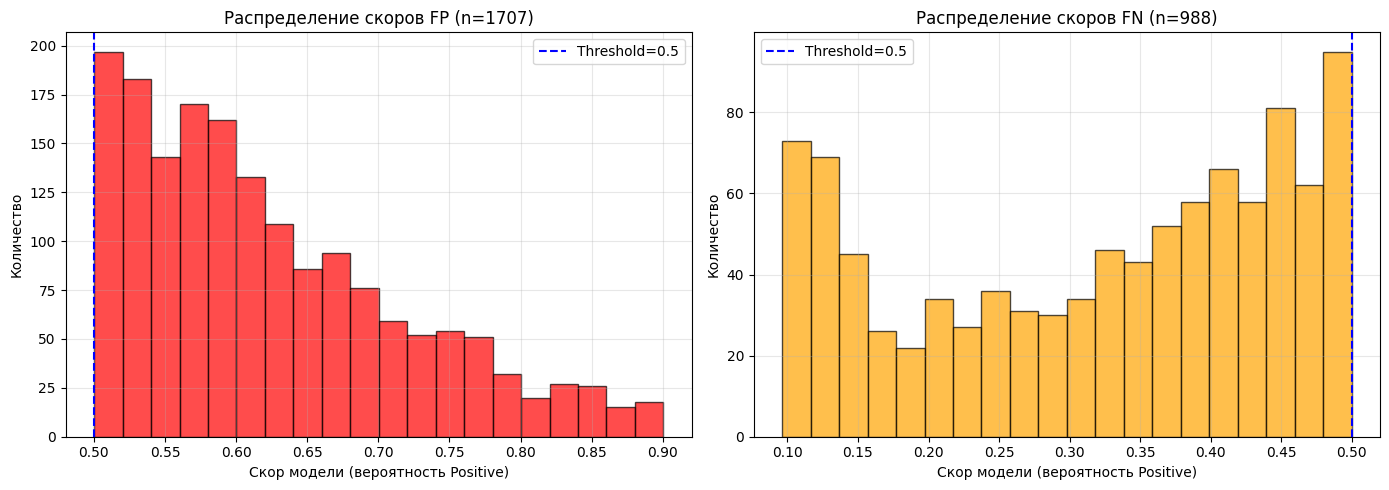

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение для FP
if len(fp_df) > 0:
    axes[0].hist(fp_df['model_score'], bins=20, alpha=0.7, color='red', edgecolor='black')
    axes[0].axvline(x=0.5, color='blue', linestyle='--', label='Threshold=0.5')
    axes[0].set_xlabel('Скор модели (вероятность Positive)')
    axes[0].set_ylabel('Количество')
    axes[0].set_title(f'Распределение скоров FP (n={len(fp_df)})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    

# Распределение для FN
if len(fn_df) > 0:
    axes[1].hist(fn_df['model_score'], bins=20, alpha=0.7, color='orange', edgecolor='black')
    axes[1].axvline(x=0.5, color='blue', linestyle='--', label='Threshold=0.5')
    axes[1].set_xlabel('Скор модели (вероятность Positive)')
    axes[1].set_ylabel('Количество')
    axes[1].set_title(f'Распределение скоров FN (n={len(fn_df)})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

Отсмотрим скорее всего ошибки датасета по принцпу высокой уверенности модели в противоположном ответе

In [57]:
# Добавляем столбцы в датафрейм
df_test['model_score'] = final_predictions
df_test['predicted_label'] = (final_predictions > 0.5).astype(int)

# Выводим примеры FP (ложные срабатывания)
fp_df = df_test[(df_test['predicted_label'] == 1) & (df_test['label'] == 0) & (df_test['model_score'] > 0.9)]
print(f"\nFalse Positives (FP): {len(fp_df)}")
print("="*80)
for idx, row in fp_df.sample(min(3, len(fp_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Positives (FP): 1
СКОР от модели: 0.9005
Rating на сайте: 5.0000
ТЕКСТ: Ужасное обслуживание в данном магазине(((Продавцы не умеют пользоваться кассовым аппаратом,не знают куда нажать для оплаты по Q коду,потом у них не выходит чек и они не отдают продукты,предлагая оплат...
--------------------------------------------------------------------------------


In [58]:
# Выводим примеры FN (пропущенные цели)
fn_df = df_test[(df_test['predicted_label'] == 0) & (df_test['label'] == 1) & (df_test['model_score'] < 0.1)]
print(f"\nFalse Negatives (FN): {len(fn_df)}")
print("="*80)
for idx, row in fn_df.sample(min(3, len(fn_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Negatives (FN): 6
СКОР от модели: 0.0973
Rating на сайте: 1.0000
ТЕКСТ: Интересненькое, любопытное местечко, не ожидал! Ехал поиграть в теннис, а получил" Много флаконов в одном" —вкусняшка еда с красивой подачей, что делает сумасшедшим Аппетит, комфортабельный номер с бе...
--------------------------------------------------------------------------------
СКОР от модели: 0.0992
Rating на сайте: 0.0000
ТЕКСТ: Прекрасное место для отдыха компанией или семье. Цены дешёвые. Ехали мимо на Лаго-Наки, остановились с палатками. По пути обратно было решено остановится на 2 дня. Пляж, детская площадка, нормальный с...
--------------------------------------------------------------------------------
СКОР от модели: 0.0966
Rating на сайте: 2.0000
ТЕКСТ: Это лучшее место на земле❤️. Девочковый рай, там всегда красиво и стильно, занятия ведут самые красивые девочки, Вика и Надя, каждому стараются уделить внимание,  помогают, подсказывают. Очень тактичн...
---------------------------------------

---

## Оценка качества на своих примерах

In [59]:
# Функция для предсказания на новых данных
def predict_texts(model, tokenizer, texts, device):
    model.eval()
    predictions = []
    
    for text in texts:
        encoding = tokenizer(
            str(text),
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        
        with torch.no_grad():
            output = model(input_ids, attention_mask)
            prob = torch.sigmoid(output).cpu().item()
            predictions.append(prob)
    
    return predictions

In [65]:
test_texts = [
    "Хорошее место. могу рекомендовать",
    "Хуже места не встечал!",
    "Это место топ1 с конца по качеству",
    "Капец как плохо в этом заведении",
    "Капец как хорошо в этом заведении",
]
predict_texts(model=model, tokenizer=tokenizer, texts=test_texts, device=device)

[0.11301853507757187,
 0.8370214700698853,
 0.18391741812229156,
 0.8056371212005615,
 0.4864628314971924]

### lime интерпретация модели

Probabilities: Neg=0.149, Pos=0.851
Predicted: Negative


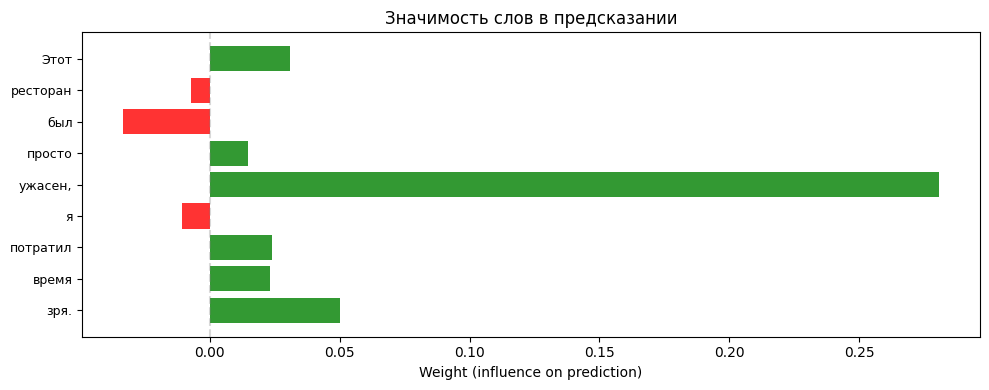

In [66]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer

def create_lime_predictor(model, tokenizer, device, max_length=512):
    model.eval()
    def predictor(texts):
        probs = []
        with torch.no_grad():
            for text in texts:
                enc = tokenizer(str(text), truncation=True, padding='max_length', 
                               max_length=max_length, return_tensors='pt')
                input_ids = enc['input_ids'].to(device)
                attention_mask = enc['attention_mask'].to(device)
                output = model(input_ids, attention_mask)
                prob_1 = torch.sigmoid(output).cpu().item()
                probs.append([1-prob_1, prob_1])
        return np.array(probs)
    return predictor

def plot_lime_explanation_original_order(explanation, text, top_n=10, figsize=(10, 4)):
    """Визуализация в порядке исходного текста"""
    # Получаем все слова с весами
    lime_dict = {word: weight for word, weight in explanation.as_list()}
    
    # Разбиваем исходный текст на слова (в оригинальном порядке)
    words_in_order = text.split()
    
    # Берём только те слова, для которых есть веса от LIME
    words = []
    weights = []
    for word in words_in_order:
        # Очищаем слово от знаков препинания для поиска
        clean_word = word.strip('.,!?;:')
        if clean_word in lime_dict and len(words) < top_n:
            words.append(word)
            weights.append(lime_dict[clean_word])
    
    colors = ['green' if w > 0 else 'red' for w in weights]
    
    plt.figure(figsize=figsize)
    plt.barh(range(len(words)), weights, color=colors, alpha=0.8)
    plt.yticks(range(len(words)), words, fontsize=9)
    plt.xlabel('Weight (influence on prediction)')
    plt.title(f'Значимость слов в предсказании')
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

text = "Этот ресторан был просто ужасен, я потратил время зря."
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

Probabilities: Neg=0.696, Pos=0.304
Predicted: Negative


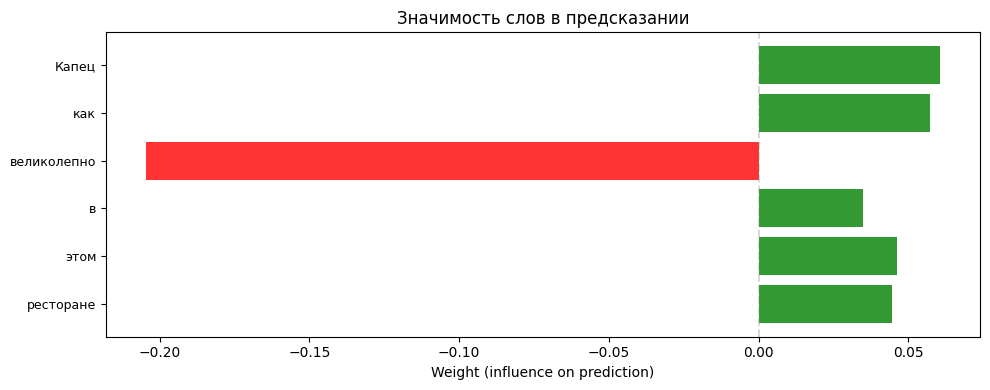

In [69]:
# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

text = "Капец как великолепно в этом ресторане"
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

---

### Перевод модели в ONNX

In [68]:
# Конвертация модели в ONNX
def convert_to_onnx(model, tokenizer, device, output_path="model.onnx", max_length=64):
    model.eval()
    
    # Создаем псевдо текст через токенизатор
    dummy_text = "dummy text for onnx export"
    dummy_inputs = tokenizer(dummy_text, truncation=True, padding='max_length', 
                            max_length=max_length, return_tensors='pt')
    
    dummy_input_ids = dummy_inputs['input_ids'].to(device)
    dummy_attention_mask = dummy_inputs['attention_mask'].to(device)
    
    # Экспортируем в ONNX
    torch.onnx.export(
        model,
        (dummy_input_ids, dummy_attention_mask),
        output_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['output'],
        dynamic_axes={'input_ids': {0: 'batch_size'}, 'attention_mask': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
        opset_version=14
    )
    
    print(f"Модель сохранена в {output_path}")

# Сохраняем модель
convert_to_onnx(model, tokenizer, device, "model.onnx", MAX_LENGTH)

Модель сохранена в model.onnx
